# Step 2: CoreLogic Trim + QA/QC

Russell Blessing

In [ ]:
library(readr)
library(dplyr)



Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Linking to GEOS 3.12.0, GDAL 3.11.0, PROJ 9.2.1; sf_use_s2() is TRUE

Raw CoreLogic CSV: /proj/mhinolab/projects/obstacles2/CRC_May_2025/Raw Data Inputs/Core Logic NC/statedf_NC_2024-11-05.csv 

Parcels GPKG : /proj/mhinolab/users/rbless/data/Obstacles_Output/parcels_study_area.gpkg 

Cleaned Corelogic CSV  : /proj/mhinolab/users/rbless/data/Obstacles_Output/cl.csv 

In [ ]:

# Read all columns as character to preserve leading zeros in FIPS codes and other IDs
cl <- readr::read_csv(
  corelogic_csv,
  col_types = cols(.default = col_character())
)

# Load study area parcels from GeoPackage
parcels <- sf::st_read(parcels_gpkg, quiet = TRUE)

# Confirm required join keys exist in both datasets before proceeding
stopifnot("cntyfips" %in% names(parcels))
stopifnot("FIPS CODE" %in% names(cl))

cat("CoreLogic rows:", nrow(cl), " cols:", ncol(cl), "\n")
cat("Parcels rows  :", nrow(parcels), " cols:", ncol(parcels), "\n")


In [ ]:

# Build the county FIPS list from parcels, prefixed with "37" (NC state code)
cntyfips_list <- parcels |>
  sf::st_drop_geometry() |>
  dplyr::distinct(cntyfips) |>
  dplyr::mutate(fips_full = paste0("37", cntyfips)) |>
  dplyr::pull(fips_full)

# Trim CoreLogic to study area counties and drop duplicates
cl_trim <- cl |>
  dplyr::filter(`FIPS CODE` %in% cntyfips_list) |>
  dplyr::distinct() |>
  dplyr::mutate(cl_index = dplyr::row_number())

# Select columns of interest
desired_columns <- c(
  "CLIP", "FIPS CODE", "APN (PARCEL NUMBER UNFORMATTED)", "APN SEQUENCE NUMBER",
  "ORIGINAL APN", "ONLINE FORMATTED PARCEL ID", "ALTERNATE PARCEL ID",
  "SITUS HOUSE NUMBER", "SITUS STREET NAME", "SITUS CITY", "SITUS ZIP CODE",
  "MAILING HOUSE NUMBER", "MAILING STREET NAME", "MAILING CITY", "MAILING ZIP CODE",
  "PARCEL LEVEL LATITUDE", "PARCEL LEVEL LONGITUDE", "LAND USE CODE",
  "COUNTY USE DESCRIPTION", "STATE USE DESCRIPTION", "ZONING CODE DESCRIPTION",
  "PROPERTY INDICATOR CODE", "TOTAL VALUE CALCULATED", "LAND VALUE CALCULATED",
  "IMPROVEMENT VALUE CALCULATED", "ASSESSED TOTAL VALUE", "ASSESSED LAND VALUE",
  "ASSESSED IMPROVEMENT VALUE", "MARKET TOTAL VALUE", "MARKET LAND VALUE",
  "MARKET IMPROVEMENT VALUE", "ACRES", "YEAR BUILT", "EFFECTIVE YEAR BUILT",
  "OWNER 1 FULL NAME", "cl_index"
)

cl_trim <- cl_trim |>
  dplyr::select(dplyr::any_of(desired_columns))

# Save
readr::write_csv(cl_trim, output_csv)


In [ ]:
cl_trim <- readr::read_csv("/proj/mhinolab/users/rbless/data/Obstacles_Output/cl.csv",
                           col_types = cols(.default = col_character()))


In [ ]:
numeric_cols <- c(
  "TOTAL VALUE CALCULATED", "LAND VALUE CALCULATED", "IMPROVEMENT VALUE CALCULATED",
  "ASSESSED TOTAL VALUE", "ASSESSED LAND VALUE", "ASSESSED IMPROVEMENT VALUE",
  "MARKET TOTAL VALUE", "MARKET LAND VALUE", "MARKET IMPROVEMENT VALUE",
  "ACRES", "PARCEL LEVEL LATITUDE", "PARCEL LEVEL LONGITUDE"
)

integer_cols <- c(
  "APN SEQUENCE NUMBER", "PROPERTY INDICATOR CODE", "cl_index"
)

year_cols <- c("YEAR BUILT", "EFFECTIVE YEAR BUILT")

factor_cols <- c(
  "LAND USE CODE", "COUNTY USE DESCRIPTION", "STATE USE DESCRIPTION",
  "ZONING CODE DESCRIPTION", "PROPERTY INDICATOR CODE", "FIPS CODE"
)

cl_trim <- cl_trim |>
  mutate(
    across(all_of(numeric_cols), as.numeric),
    across(all_of(year_cols),    ~ suppressWarnings(as.integer(.))),
    across(all_of(integer_cols), ~ suppressWarnings(as.integer(.))),
    across(all_of(factor_cols),  as.factor)
  )


The trimmed CoreLogic dataset contains 4,631,388 property records across 78 counties in the study area.

In [ ]:
cl_trim |>
  summarise(across(everything(), ~ mean(is.na(.)) * 100)) |>
  pivot_longer(everything(), names_to = "variable", values_to = "pct_missing") |>
  arrange(desc(pct_missing)) |>
  gt() |>
  tab_header(title = "Missingness by Variable") |>
  fmt_number(columns = pct_missing, decimals = 1) |>
  cols_label(
    variable    = "Variable",
    pct_missing = "% Missing"
  )


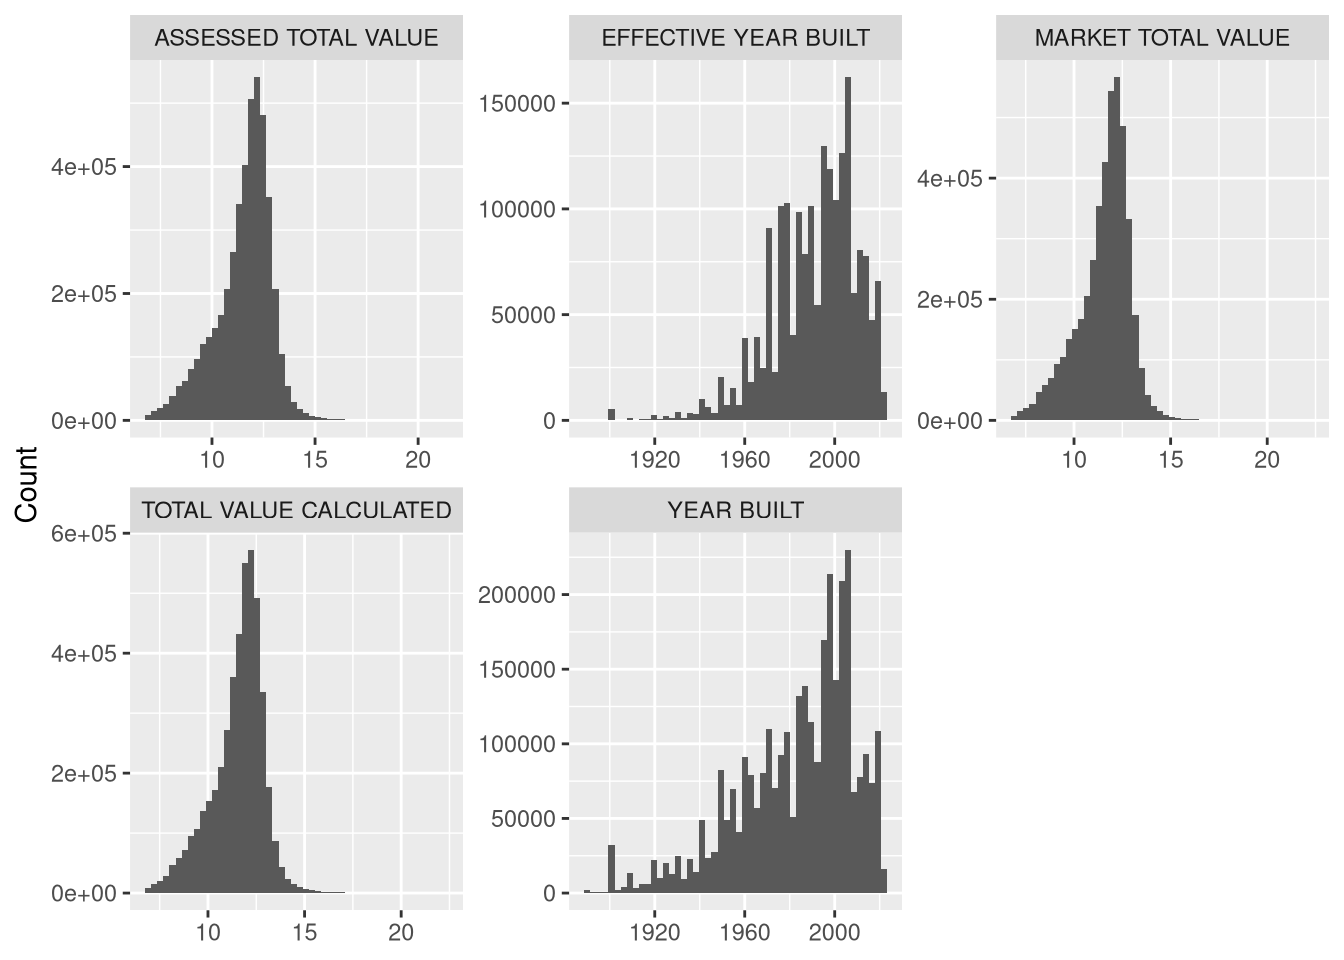

In [ ]:
hist_vars <- c(
  "TOTAL VALUE CALCULATED",
  "ASSESSED TOTAL VALUE",
  "MARKET TOTAL VALUE",
  "YEAR BUILT",
  "EFFECTIVE YEAR BUILT"
)

value_vars <- c("TOTAL VALUE CALCULATED", "ASSESSED TOTAL VALUE", "MARKET TOTAL VALUE")
year_vars  <- c("YEAR BUILT", "EFFECTIVE YEAR BUILT")


cl_trim |>
  select(all_of(hist_vars)) |>
  mutate(across(everything(), as.numeric)) |>
  mutate(across(all_of(value_vars), ~ if_else(. < 1000, NA_real_, log1p(.)))) |>
  mutate(across(all_of(year_vars),  ~ if_else(. < 1890, NA_real_, .))) |>
  pivot_longer(everything(), names_to = "variable", values_to = "value") |>
  filter(!is.na(value)) |>
  ggplot(aes(x = value)) +
  geom_histogram(bins = 50) +
  facet_wrap(~ variable, scales = "free") +
  labs(x = NULL, y = "Count")


In [ ]:
cl_trim |>
  select(all_of(hist_vars)) |>
  mutate(across(everything(), as.numeric)) |>
  summarise(across(everything(), list(
    min    = ~ min(.,    na.rm = TRUE),
    median = ~ median(., na.rm = TRUE),
    mean   = ~ mean(.,   na.rm = TRUE),
    max    = ~ max(.,    na.rm = TRUE)
  ))) |>
  pivot_longer(everything(),
               names_to  = c("variable", ".value"),
               names_sep = "_(?=[^_]+$)") |>
  arrange(variable) |>
  gt() |>
  tab_header(title = "Summary Statistics for Selected Variables") |>
  fmt_number(
    columns = c(min, median, mean, max),
    rows    = variable %in% value_vars,
    decimals = 0
  ) |>
  fmt_number(
    columns = c(min, median, mean, max),
    rows    = variable %in% year_vars,
    decimals = 1,
    use_seps = FALSE
  ) |>
  cols_label(
    variable = "Variable",
    min      = "Min",
    median   = "Median",
    mean     = "Mean",
    max      = "Max"
  )
